<a href="https://colab.research.google.com/github/iqrahussainn/Crime-investigation-system/blob/main/231184_231222_Final_Proejct_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **From Assignment # 01**

In [ ]:
import os
import cv2
import nibabel as nib
import numpy as np

# dataset folder
dataset = "/content/drive/MyDrive/group 10/group 10"

# folder for saving processed images
processed_folder = "/content/drive/MyDrive/Processed_MRI"
os.makedirs(processed_folder, exist_ok=True)

# getting all patient folders
patients = os.listdir(dataset)

# loop through patient folders
for patient in patients:

    patient_path = os.path.join(dataset, patient)

    # skip if not a folder
    if not os.path.isdir(patient_path):
        continue

    # using t1c MRI image
    mri_file = [f for f in os.listdir(patient_path)
                if "t1c" in f][0]
    mri_path = os.path.join(patient_path, mri_file)

    # load MRI image
    img = nib.load(mri_path)
    data = img.get_fdata()

    # using middle slice
    middle = data.shape[2] // 2
    slice_img = data[:, :, middle]

    # normalize image
    slice_img = cv2.normalize( slice_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # gaussian filter
    gaussian = cv2.GaussianBlur(slice_img, (5,5), 0)

    # mean filter
    mean = cv2.blur( gaussian, (3,3))

    # median filter
    median = cv2.medianBlur( mean, 3)

    # anti aliasing before downsampling
    anti_alias = cv2.GaussianBlur(median, (3,3), 0)

    # downsampling image
    resized = cv2.resize( anti_alias, (anti_alias.shape[1] // 2, anti_alias.shape[0] // 2))

    # save processed image
    save_path = os.path.join( processed_folder, patient + ".png")

    cv2.imwrite( save_path,resized)

print("processed MRI Images")

processed MRI Images


### **From Assignment # 02**

In [ ]:
import os
import cv2
import numpy as np

# folder containing processed MRI images from Assignment 1
processed_folder = "/content/drive/MyDrive/Processed_MRI"

# folder for saving segmented masks
mask_folder = "/content/drive/MyDrive/Segmented_Masks"

os.makedirs(mask_folder, exist_ok=True)

# get all processed images
images = os.listdir(processed_folder)

# loop through images
for image in images:

    path = os.path.join( processed_folder, image)

    # load image in grayscale
    img = cv2.imread(path,cv2.IMREAD_GRAYSCALE)

    # Sobel edge detection in x direction
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

    # Sobel edge detection in y direction
    sobely = cv2.Sobel( img, cv2.CV_64F, 0, 1, ksize=3)

    # calculate gradient magnitude
    magnitude = np.sqrt(sobelx**2 + sobely**2)

    # normalize image
    magnitude = cv2.normalize( magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # convert edge image into binary mask
    _, binary = cv2.threshold( magnitude, 50, 255, cv2.THRESH_BINARY)

    # kernel for morphological operations
    kernel = np.ones((3,3), np.uint8)

    # erosion removes small noisy pixels
    erosion = cv2.erode( binary, kernel, iterations=1)

    # dilation restores object size
    dilation = cv2.dilate( erosion, kernel, iterations=1)

    # opening removes small artifacts
    opening = cv2.morphologyEx(dilation, cv2.MORPH_OPEN, kernel)

    # closing fills small holes
    closing = cv2.morphologyEx( opening, cv2.MORPH_CLOSE, kernel)

    # save final segmented mask
    save_path = os.path.join(mask_folder, image)

    cv2.imwrite(save_path, closing)

print("Segmented Masks completed")

Segmented Masks completed


### **From Assignment # 03**

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

from skimage.feature import graycomatrix
from skimage.feature import graycoprops

# folder
processed_folder = "/content/drive/MyDrive/Processed_MRI"
mask_folder = "/content/drive/MyDrive/Segmented_Masks"

# storing features
feature_data = []

# loop through images
images = os.listdir(processed_folder)

for image in images:
    print("Processing:", image)

    # MRI image

    img_path = os.path.join(processed_folder, image)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # mask
    mask_path = os.path.join(mask_folder, image)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        continue

    # apply mask

    masked_region = cv2.bitwise_and(img, img, mask=mask)

    # GLCM
    glcm = graycomatrix(masked_region, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    # statistical features
    energy = graycoprops( glcm,"energy")[0,0]

    contrast = graycoprops(glcm,"contrast")[0,0]

    glcm_prob = glcm / np.sum(glcm)

    entropy = -np.sum(glcm_prob * np.log2(glcm_prob + 1e-10))

    # geometric features
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        continue

    contour = max(contours, key=cv2.contourArea)

    # area
    area = cv2.contourArea(contour)

    # perimeter
    perimeter = cv2.arcLength(contour,True)

    # circularity
    circularity = (4 * np.pi * area) / (perimeter * perimeter + 1e-10)

    # centroid
    M = cv2.moments(contour)

    cx = int(M["m10"] /(M["m00"] + 1e-10))

    cy = int(M["m01"] /(M["m00"] + 1e-10))

    # save features

    feature_data.append([
        image,
        energy,
        entropy,
        contrast,
        area,
        perimeter,
        circularity,
        cx,
        cy
    ])

# dataframe

columns = [
    "Image",
    "Energy",
    "Entropy",
    "Contrast",
    "Area",
    "Perimeter",
    "Circularity",
    "Centroid_X",
    "Centroid_Y"
]

df = pd.DataFrame(
    feature_data,
    columns=columns
)

# save csv

csv_path = "/content/drive/MyDrive/Feature_Vector.csv"

df.to_csv(csv_path,index=False)

print("\nCSV Saved")

print(df.head())

Processing: BraTS-PED-00246-000.png
Processing: BraTS-PED-00251-000.png
Processing: BraTS-PED-00245-000.png
Processing: BraTS-PED-00241-000.png
Processing: BraTS-PED-00244-000.png
Processing: BraTS-PED-00243-000.png
Processing: BraTS-PED-00242-000.png
Processing: BraTS-PED-00248-000.png
Processing: BraTS-PED-00239-000.png
Processing: BraTS-PED-00247-000.png
Processing: BraTS-PED-00240-000.png
Processing: BraTS-PED-00238-000.png
Processing: BraTS-PED-00236-000.png
Processing: BraTS-PED-00249-000.png
Processing: BraTS-PED-00237-000.png
Processing: BraTS-PED-00235-000.png
Processing: BraTS-PED-00230-000.png
Processing: BraTS-PED-00233-000.png
Processing: BraTS-PED-00226-000.png
Processing: BraTS-PED-00234-000.png
Processing: BraTS-PED-00227-000.png
Processing: BraTS-PED-00231-000.png
Processing: BraTS-PED-00228-000.png
Processing: BraTS-PED-00232-000.png
Processing: BraTS-PED-00229-000.png

CSV Saved
                     Image    Energy   Entropy    Contrast   Area   Perimeter  \
0  BraTS

### **For Making Labels**

In [ ]:
import os
import shutil
import pandas as pd

csv_file = "/content/drive/MyDrive/Feature_Vector.csv"

images_folder = "/content/drive/MyDrive/Processed_MRI"

dataset_folder = "/content/drive/MyDrive/BrainTumorDataset"

high_folder = os.path.join(dataset_folder, "High_Risk")
low_folder = os.path.join(dataset_folder, "Low_Risk")

os.makedirs(high_folder, exist_ok=True)
os.makedirs(low_folder, exist_ok=True)

df = pd.read_csv(csv_file)
median_area = df["Area"].median()

for _, row in df.iterrows():
    image_name = row["Image"]
    area = row["Area"]

    source = os.path.join(images_folder,image_name)

    if area > median_area:

        destination = os.path.join(high_folder,image_name)

    else:

        destination = os.path.join(low_folder,image_name)

    shutil.copy(source,destination)

print("Dataset Created")

Dataset Created


### **CNN**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# dataset folder
dataset_path = "/content/drive/MyDrive/BrainTumorDataset"

# image size
img_height = 128
img_width = 128

# loading dataset
dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(img_height, img_width),
    batch_size=8,
    color_mode="grayscale",
    shuffle=True
)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128,128),
    batch_size=8,
    color_mode="grayscale"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128,128),
    batch_size=8,
    color_mode="grayscale"
)

# cnn model
model = Sequential()

# first convolution layer
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(128,128,1)))

# first pooling layer
model.add(MaxPooling2D((2,2)))

# second convolution layer
model.add(Conv2D(64,(3,3),activation="relu"))

# second pooling layer
model.add(MaxPooling2D((2,2)))

# third convolution layer
model.add(Conv2D(128,(3,3), activation="relu"))

# third pooling layer
model.add(MaxPooling2D((2,2)))

# flatten feature maps
model.add(Flatten())

# dense layer
model.add(Dense(128, activation="relu"))

# dropout to reduce overfitting
model.add(Dropout(0.5))

# output layer
model.add(Dense(1,activation="sigmoid"))

# compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# model summary
model.summary()

# training model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20
)

# evaluate model
loss, accuracy = model.evaluate(
    test_dataset
)

print("\nTest Accuracy:", accuracy)

Found 25 files belonging to 2 classes.
Found 25 files belonging to 2 classes.
Using 20 files for training.
Found 25 files belonging to 2 classes.
Using 5 files for validation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 466ms/step - accuracy: 0.3500 - loss: 40.4414 - val_accuracy: 0.4000 - val_loss: 8.1586
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 425ms/step - accuracy: 0.5500 - loss: 8.0240 - val_accuracy: 0.4000 - val_loss: 1.5072
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 400ms/step - accuracy: 0.7500 - loss: 1.1708 - val_accuracy: 0.8000 - val_loss: 0.5740
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step - accuracy: 0.6500 - loss: 1.1354 - val_accuracy: 0.8000 - val_loss: 0.7047
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 0.5500 - loss: 0.9225 - val_accuracy: 0.4000 - val_loss: 1.0920
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.7000 - loss: 0.5440 - val_accuracy: 0.4000 - val_loss: 0.7333
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step - accuracy: 0.6000 - loss: 0.6508 - val_accuracy: 0.4000 - val_loss: 0.7238
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.8000 - loss: 0.4695 - val_accuracy: 0.4000 - val_loss

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 1.0000 - loss: 0.0839 - val_accuracy: 0.4000 - val_loss: 2.3586
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 1.0000 - loss: 0.0612 - val_accuracy: 0.6000 - val_loss: 2.1734
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step - accuracy: 1.0000 - loss: 0.0448 - val_accuracy: 0.6000 - val_loss: 2.2886
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 394ms/step - accuracy: 1.0000 - loss: 0.0204 - val_accuracy: 0.4000 - val_loss: 2.5947
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 380ms/step - accuracy: 1.0000 - loss: 0.0561 - val_accuracy: 0.6000 - val_loss: 2.6252
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 581ms/step - accuracy: 1.0000 - loss: 0.0403 - val_accuracy: 0.6000 - val_loss: 2.6072
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 612ms/step - accuracy: 0.9500 - loss: 0.0855 - val_accuracy: 0.4000 - val_loss: 5.2117
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 720ms/step - accuracy: 1.0000 - loss: 0.0340 - val_accuracy: 0.4000 - val_loss:

In [ ]:
import numpy as np

# store actual labels
y_true = []

# store predicted labels
y_pred = []

# loop through test data
for images, labels in test_dataset:
    predictions = model.predict(images)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())

    y_pred.extend(predictions.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[1 2]
 [0 2]]


**CLASSIFICATION REPORT**

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Low_Risk",
            "High_Risk"
        ]
    )
)

              precision    recall  f1-score   support

    Low_Risk       1.00      0.33      0.50         3
   High_Risk       0.50      1.00      0.67         2

    accuracy                           0.60         5
   macro avg       0.75      0.67      0.58         5
weighted avg       0.80      0.60      0.57         5



**CONFUSION MATRIX**

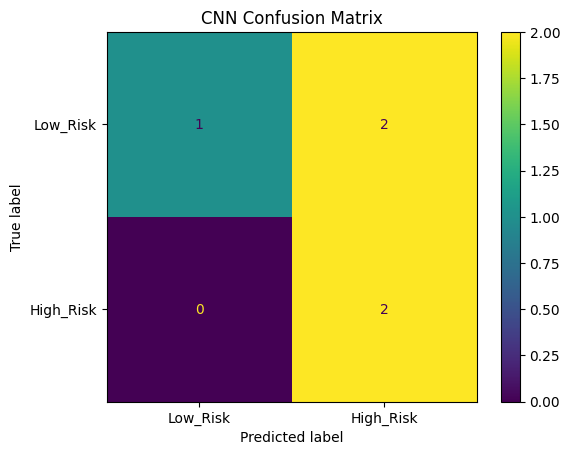

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Low_Risk",
        "High_Risk"
    ]
)

disp.plot()

plt.title(
    "CNN Confusion Matrix"
)

plt.show()

**ACCURACY PLOT**

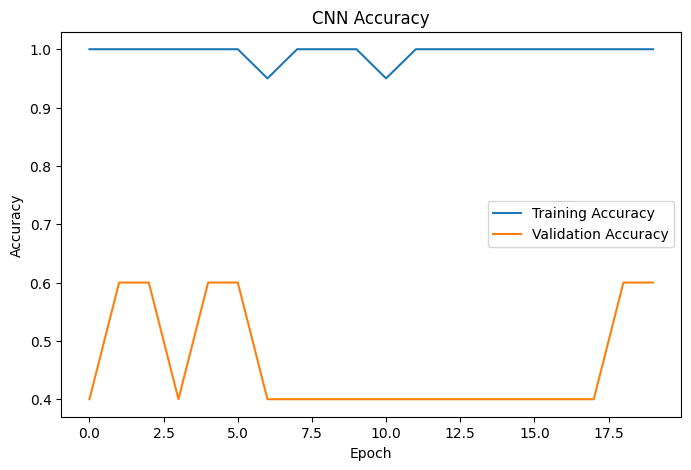

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "CNN Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

**LOSS PLOT**

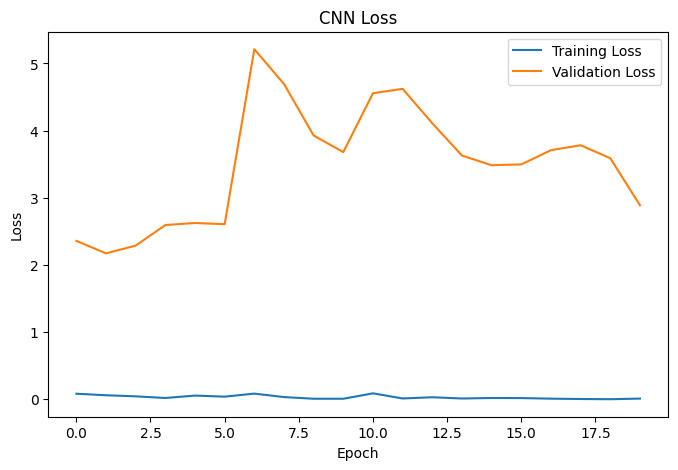

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "CNN Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

### **Transformer**

**Load MRI Volumes**

In [ ]:
import os
import nibabel as nib
import numpy as np

from scipy.ndimage import zoom

# dataset

dataset = "/content/drive/MyDrive/group 10/group 10"

patients = os.listdir(dataset)

# storage

X = []

tumor_sizes = []

patient_names = []

# ==========================
# First Pass
# ==========================

for patient in patients:

    patient_path = os.path.join(
        dataset,
        patient
    )

    if not os.path.isdir(patient_path):
        continue

    print("Processing:", patient)

    # t1c MRI

    mri_file = [
        f for f in os.listdir(patient_path)
        if "t1c" in f
    ][0]

    # segmentation file

    seg_file = [
        f for f in os.listdir(patient_path)
        if "seg" in f
    ][0]

    # load MRI

    mri_path = os.path.join(
        patient_path,
        mri_file
    )

    mri = nib.load(
        mri_path
    )

    volume = mri.get_fdata()

    # load segmentation

    seg_path = os.path.join(
        patient_path,
        seg_file
    )

    seg = nib.load(
        seg_path
    )

    mask = seg.get_fdata()

    # tumor size

    tumor_pixels = np.sum(
        mask > 0
    )

    tumor_sizes.append(
        tumor_pixels
    )

    patient_names.append(
        patient
    )

    # apply mask

    tumor_volume = volume * (
        mask > 0
    )

    # normalize

    tumor_volume = (

        tumor_volume -

        tumor_volume.min()

    ) / (

        tumor_volume.max()

        -

        tumor_volume.min()

        +

        1e-10
    )

    # resize volume

    tumor_volume = zoom(

        tumor_volume,

        (

            64 / tumor_volume.shape[0],

            64 / tumor_volume.shape[1],

            64 / tumor_volume.shape[2]

        )
    )

    # add channel dimension

    tumor_volume = np.expand_dims(

        tumor_volume,

        axis=-1
    )

    X.append(
        tumor_volume
    )

# ==========================
# Median Tumor Size
# ==========================

median_size = np.median(
    tumor_sizes
)

print("\nMedian Tumor Size:", median_size)

# ==========================
# Create Labels
# ==========================

y = []

for size in tumor_sizes:

    if size > median_size:

        label = 1

    else:

        label = 0

    y.append(label)

# numpy arrays

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(
    y
)

# check balance

unique, counts = np.unique(
    y,
    return_counts=True
)

print("\nClass Distribution:")

for u, c in zip(unique, counts):

    print(
        "Class",
        u,
        ":",
        c
    )

print("\nX Shape:", X.shape)

print("y Shape:", y.shape)

Processing: BraTS-PED-00246-000
Processing: BraTS-PED-00251-000
Processing: BraTS-PED-00245-000
Processing: BraTS-PED-00241-000
Processing: BraTS-PED-00244-000
Processing: BraTS-PED-00243-000
Processing: BraTS-PED-00242-000
Processing: BraTS-PED-00248-000
Processing: BraTS-PED-00239-000
Processing: BraTS-PED-00247-000
Processing: BraTS-PED-00240-000
Processing: BraTS-PED-00238-000
Processing: BraTS-PED-00236-000
Processing: BraTS-PED-00249-000
Processing: BraTS-PED-00237-000
Processing: BraTS-PED-00235-000
Processing: BraTS-PED-00230-000
Processing: BraTS-PED-00233-000
Processing: BraTS-PED-00226-000
Processing: BraTS-PED-00234-000
Processing: BraTS-PED-00227-000
Processing: BraTS-PED-00231-000
Processing: BraTS-PED-00228-000
Processing: BraTS-PED-00232-000
Processing: BraTS-PED-00229-000

Median Tumor Size: 35657.0

Class Distribution:
Class 0 : 13
Class 1 : 12

X Shape: (25, 64, 64, 64, 1)
y Shape: (25,)


**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**3D CNN + Transformer**

In [ ]:
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Model

# input layer

inputs = tf.keras.Input(
    shape=(64,64,64,1)
)

# first 3D convolution

x = layers.Conv3D(
    32,
    (3,3,3),
    activation="relu",
    padding="same"
)(inputs)

# pooling

x = layers.MaxPooling3D(
    (2,2,2)
)(x)

# second 3D convolution

x = layers.Conv3D(
    64,
    (3,3,3),
    activation="relu",
    padding="same"
)(x)

# pooling

x = layers.MaxPooling3D(
    (2,2,2)
)(x)

# third 3D convolution

x = layers.Conv3D(
    128,
    (3,3,3),
    activation="relu",
    padding="same"
)(x)

# reshape for transformer

x = layers.Reshape(
    (-1,128)
)(x)

# transformer block

attention = layers.MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(x,x)

# residual connection

x = layers.Add()(
    [x, attention]
)

# normalization
x = layers.LayerNormalization()(x)

# pooling
x = layers.GlobalAveragePooling1D()(x)

# dense layer
x = layers.Dense(
    128,
    activation="relu"
)(x)

# dropout
x = layers.Dropout(
    0.5
)(x)

# output layer
outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

# model

model = Model(
    inputs,
    outputs
)

# compile

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_6 (Conv3D)   │ (None, 64, 64,    │        896 │ input_layer_5[0]… │
│                     │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_4     │ (None, 32, 32,    │          0 │ conv3d_6[0][0]    │
│ (MaxPooling3D)      │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_7 (Conv3D)   │ (None, 32, 32,    │     55,360 │ max_pooling3d_4[… │
│                     │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_5     │ (None, 16, 16,    │          0 │ conv3d_7[0][0]    │
│ (MaxPooling3D)      │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_8 (Conv3D)   │ (None, 16, 16,    │    221,312 │ max_pooling3d_5[… │
│                     │ 16, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 4096, 128) │          0 │ conv3d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 4096, 128) │     66,048 │ reshape_3[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 4096, 128) │          0 │ reshape_3[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 4096, 128) │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │        129 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 360,513 (1.38 MB)

 Trainable params: 360,513 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_test,
        y_test
    ),

    epochs=5,
    batch_size=2
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 85s 8s/step - accuracy: 0.5500 - loss: 0.6974 - val_accuracy: 0.4000 - val_loss: 0.6942
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 88s 9s/step - accuracy: 0.4000 - loss: 0.8784 - val_accuracy: 0.6000 - val_loss: 0.6715
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 140s 8s/step - accuracy: 0.3000 - loss: 0.7675 - val_accuracy: 0.6000 - val_loss: 0.6858
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 139s 9s/step - accuracy: 0.5500 - loss: 0.7239 - val_accuracy: 0.6000 - val_loss: 0.6784
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 141s 8s/step - accuracy: 0.4500 - loss: 0.7116 - val_accuracy: 0.4000 - val_loss: 0.6929


**Evaluation**

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# prediction
y_pred = model.predict(
    X_test
)

y_pred = (
    y_pred > 0.5
).astype(int)

# confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix")

print(cm)

# precision recall f1

print(
    classification_report(
        y_test,
        y_pred
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Confusion Matrix
[[0 3]
 [0 2]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
